# Topic 1 — Logistic Regression with Python

Companion notebook for the theory file **`01_Logistic_Regression.tex`**.

Recall the recipe: **linear score $z = w_1x_1 + \dots + w_nx_n + b$ → sigmoid $\sigma(z) = 1/(1+e^{-z})$ → threshold at 0.5**. The sigmoid squashes any score into a probability in $(0,1)$, and the weights are interpretable as odds ratios via $e^{w}$.

This notebook has two parts:
1. **Part A** — the mini "bootcamp admissions" dataset from the theory chapter (6 applicants), so you can see every moving part on data small enough to check by hand.
2. **Part B** — a full real-data workflow on the **Titanic dataset** (`titanic_train.csv`): EDA, missing-data imputation, dummy variables, train/test split, training, and evaluation. We'll be trying to predict a classification — survival or deceased.

## Part A — Logistic Regression on the Bootcamp Admissions Data

The six applicants from the chapter: features are `[hours studied, practice test score]`, label is Admitted (1) / Not admitted (0).

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Features: [hours studied, practice test score]
X = np.array([[2, 45], [4, 55], [5, 60],
              [6, 62], [8, 70], [10, 85]])
y = np.array([0, 0, 0, 1, 1, 1])   # 0 = Not admitted, 1 = Admitted

# Scaling puts all features on a comparable scale,
# which helps gradient descent converge smoothly.
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [2]:
# Predict for two new applicants
new_applicants = np.array([[7, 66], [3, 50]])
print("Predicted classes :", model.predict(new_applicants))
print("Predicted probs   :", model.predict_proba(new_applicants))

Predicted classes : [1 0]
Predicted probs   : [[0.35470802 0.64529198]
 [0.82178528 0.17821472]]


In [3]:
# Inspect the learned weights
logreg = model.named_steps["logisticregression"]
print("Weights (w):", logreg.coef_)
print("Bias (b)   :", logreg.intercept_)

Weights (w): [[0.83452397 0.65961026]]
Bias (b)   : [0.05749886]


**Interpreting the output**

- `predict` returns the final class labels: the first new applicant is predicted *Admitted*, the second *Not admitted*.
- `predict_proba` returns one row per applicant with $[P(\text{class }0),\ P(\text{class }1)]$; the two numbers in each row always sum to 1.
- Both weights are positive, so more study hours **and** higher test scores both push the prediction towards admission — matching common sense, which is a good sanity check.

We can also reproduce the sigmoid by hand to confirm what `predict_proba` is doing internally:

In [4]:
# Manual sigmoid check: sigma(z) = 1 / (1 + e^(-z))
z = logreg.decision_function(model.named_steps["standardscaler"].transform(new_applicants))
sigma = 1 / (1 + np.exp(-z))
print("Linear scores z      :", z)
print("Sigmoid(z)           :", sigma)
print("P(class 1) from model:", model.predict_proba(new_applicants)[:, 1])

Linear scores z      : [ 0.59840792 -1.52849002]
Sigmoid(z)           : [0.64529198 0.17821472]
P(class 1) from model: [0.64529198 0.17821472]


## Part B — Real Data: The Titanic Dataset

For this part we work with the classic [Titanic Data Set from Kaggle](https://www.kaggle.com/c/titanic) — very often a student's first step in machine learning. We use a "semi-cleaned" version (`titanic_train.csv`); the raw Kaggle version may need extra cleaning.

### Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### The data

In [6]:
train = pd.read_csv('titanic_train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

### Missing data

We can use seaborn to create a simple heatmap to see where we are missing data.

<Axes: >

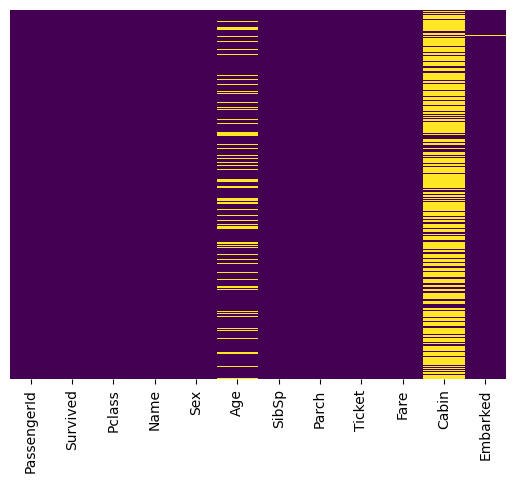

In [7]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Roughly 20 percent of the `Age` data is missing — small enough for reasonable imputation. The `Cabin` column is missing far too much to be useful at a basic level, so we will drop it later.

Some more visual exploration:

<Axes: xlabel='Survived', ylabel='count'>

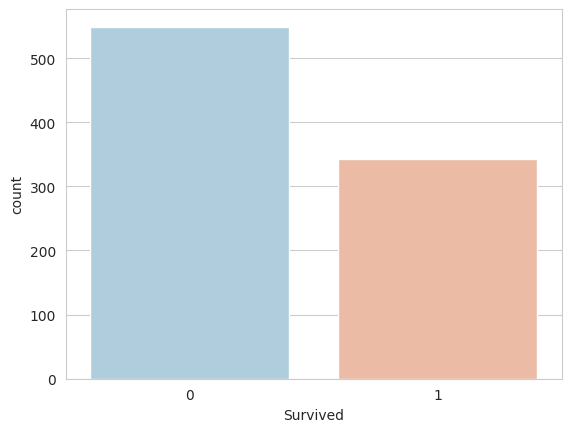

In [8]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train, palette='RdBu_r', hue='Survived', legend=False)

<Axes: xlabel='Survived', ylabel='count'>

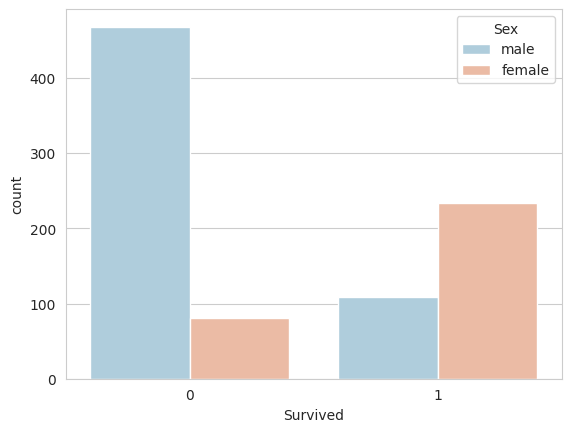

In [9]:
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

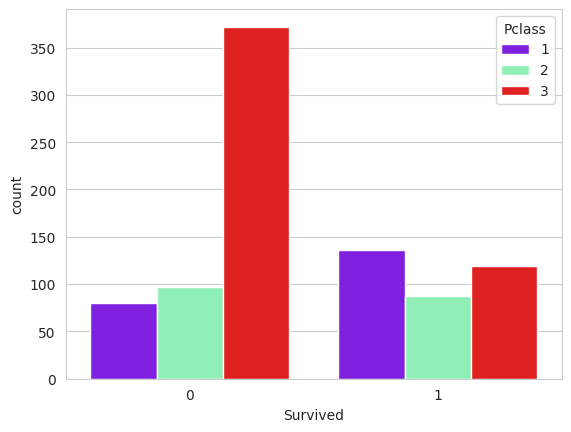

In [10]:
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')

<Axes: xlabel='Age', ylabel='Count'>

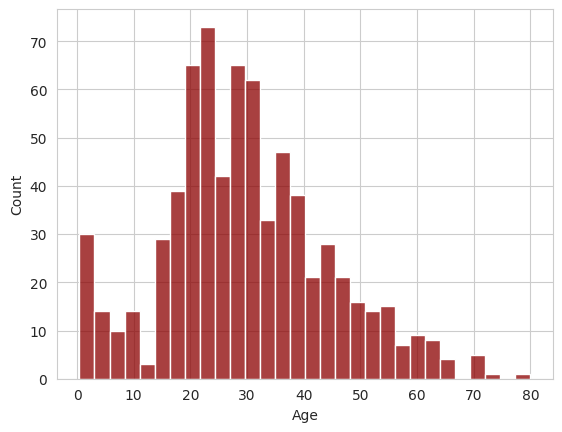

In [11]:
sns.histplot(train['Age'].dropna(), kde=False, color='darkred', bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

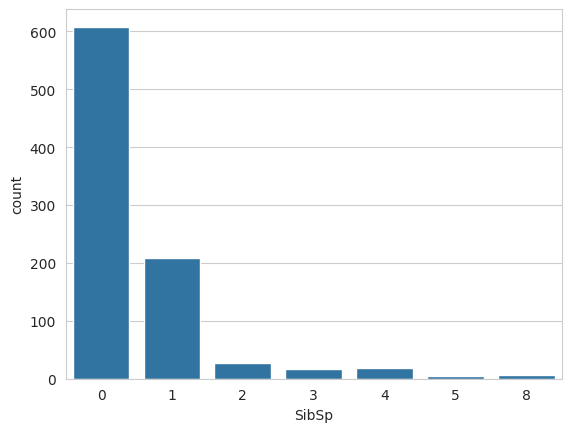

In [12]:
sns.countplot(x='SibSp', data=train)

<Axes: >

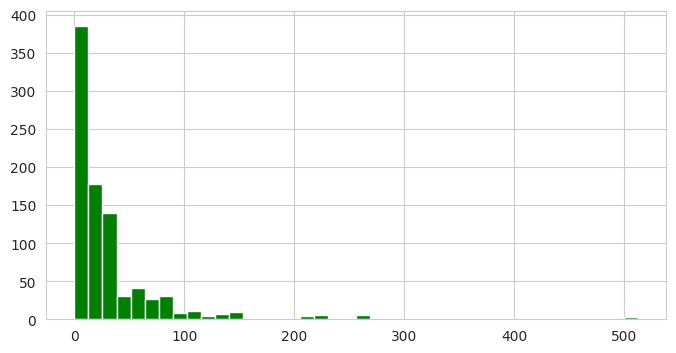

In [13]:
train['Fare'].hist(color='green', bins=40, figsize=(8, 4))

## Data Cleaning

We want to fill in missing age data instead of dropping those rows. One way is imputing the overall mean age — but we can be smarter and impute by passenger class:

<Axes: xlabel='Pclass', ylabel='Age'>

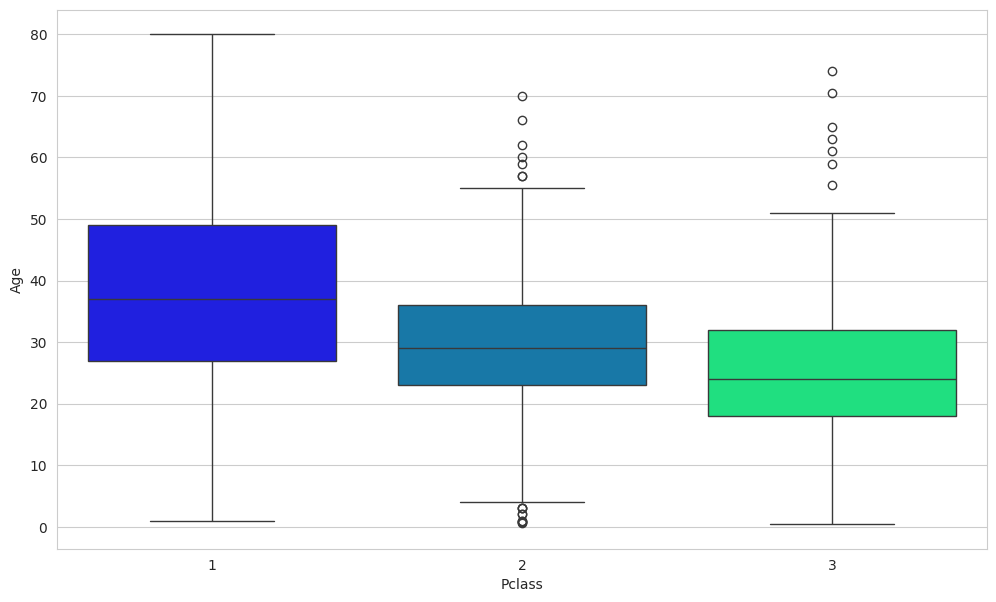

In [14]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', data=train, palette='winter', hue='Pclass', legend=False)

Wealthier passengers in the higher classes tend to be older, which makes sense. We use these class-wise average ages to impute `Age`:

In [15]:
def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

<Axes: >

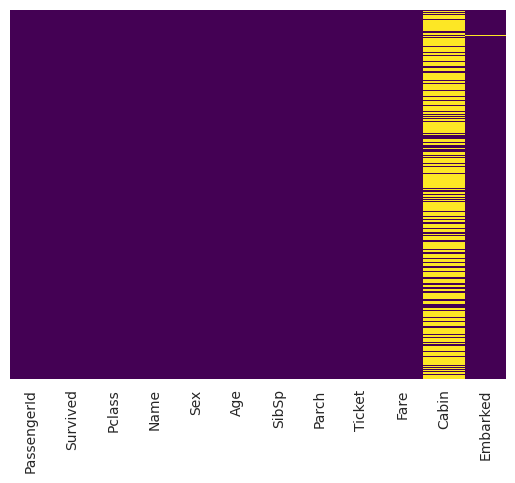

In [16]:
# Check the heatmap again — Age is now complete
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [17]:
# Drop the Cabin column and the remaining NaN row(s)
train.drop('Cabin', axis=1, inplace=True)
train.dropna(inplace=True)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Converting Categorical Features

We convert categorical features to dummy variables with pandas — otherwise the algorithm can't take them in as inputs. `drop_first=True` avoids perfect multicollinearity (one dummy is fully predictable from the others), which — as the theory file warns — makes logistic regression weights unstable.

In [18]:
sex = pd.get_dummies(train['Sex'], drop_first=True).astype(int)
embark = pd.get_dummies(train['Embarked'], drop_first=True).astype(int)

train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)
train = pd.concat([train, sex, embark], axis=1)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


## Building the Logistic Regression Model

### Train test split

We always evaluate on data the model has *not* seen during training.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Survived', axis=1),
    train['Survived'],
    test_size=0.30,
    random_state=101)

### Training and predicting

In [20]:
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
predictions = logmodel.predict(X_test)

### Evaluation

We can check precision, recall, and f1-score using the classification report (these metrics are covered in depth in Topic 4):

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[149  14]
 [ 33  71]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.82      0.82       267

